In [11]:
import importlib
import pandas as pd
import numpy as np

from scipy.spatial import ConvexHull

import polytope as pc
importlib.reload(pc)

import matplotlib.pyplot as plt

Create a dataframe containing the 16 reflexive 2D polytopes, see the paper [Unconditional Reflexive Polytopes](https://link.springer.com/article/10.1007/s00454-020-00199-8) of Florian Kohl, McCabe Olsen and Raman Sanyal.

In [12]:
polytope_data = [
    {"id": 1, "num_vertices": 3, "vertices": [[-1,2],[2,-1],[-1,-1]]},
    {"id": 2, "num_vertices": 3, "vertices": [[0,1],[1,0],[-1,-1]]},
    {"id": 3, "num_vertices": 3, "vertices": [[0,1],[2,-1],[-2,-1]]},
    {"id": 4, "num_vertices": 3, "vertices": [[0,1],[1,-1],[-1,-1]]},
    {"id": 5, "num_vertices": 4, "vertices": [[-1,1],[1,1],[1,-1],[-1,-1]]},
    {"id": 6, "num_vertices": 4, "vertices": [[0,1],[1,0],[0,-1],[-1,0]]},
    {"id": 7, "num_vertices": 5, "vertices": [[0,1],[1,0],[1,-1],[-1,-1],[-1,1]]},
    {"id": 8, "num_vertices": 5, "vertices": [[0,1],[1,0],[0,-1],[-1,-1],[-1,0]]},
    {"id": 9, "num_vertices": 4, "vertices": [[0,1],[2,-1],[-1,-1],[-1,1]]},
    {"id": 10, "num_vertices": 4, "vertices": [[0,1],[1,0],[0,-1],[-1,-1]]},
    {"id": 11, "num_vertices": 4, "vertices": [[0,1],[2,-1],[-1,-1],[-1,0]]},
    {"id": 12, "num_vertices": 4, "vertices": [[0,1],[1,0],[1,-1],[-1,-1]]},
    {"id": 13, "num_vertices": 3, "vertices": [[0,1],[2,-1],[-1,-1]]},
    {"id": 14, "num_vertices": 4, "vertices": [[0,1],[1,-1],[-1,-1],[-1,1]]},
    {"id": 15, "num_vertices": 5, "vertices": [[0,1],[1,0],[1,-1],[-1,-1],[-1,0]]},
    {"id": 16, "num_vertices": 6, "vertices": [[0,1],[1,0],[1,-1],[0,-1],[-1,0],[1,1]]}
]

df_poly2d = pd.DataFrame(polytope_data)
print(df_poly2d)

    id  num_vertices                                           vertices
0    1             3                       [[-1, 2], [2, -1], [-1, -1]]
1    2             3                         [[0, 1], [1, 0], [-1, -1]]
2    3             3                        [[0, 1], [2, -1], [-2, -1]]
3    4             3                        [[0, 1], [1, -1], [-1, -1]]
4    5             4               [[-1, 1], [1, 1], [1, -1], [-1, -1]]
5    6             4                 [[0, 1], [1, 0], [0, -1], [-1, 0]]
6    7             5       [[0, 1], [1, 0], [1, -1], [-1, -1], [-1, 1]]
7    8             5       [[0, 1], [1, 0], [0, -1], [-1, -1], [-1, 0]]
8    9             4               [[0, 1], [2, -1], [-1, -1], [-1, 1]]
9   10             4                [[0, 1], [1, 0], [0, -1], [-1, -1]]
10  11             4               [[0, 1], [2, -1], [-1, -1], [-1, 0]]
11  12             4                [[0, 1], [1, 0], [1, -1], [-1, -1]]
12  13             3                        [[0, 1], [2, -1], [-

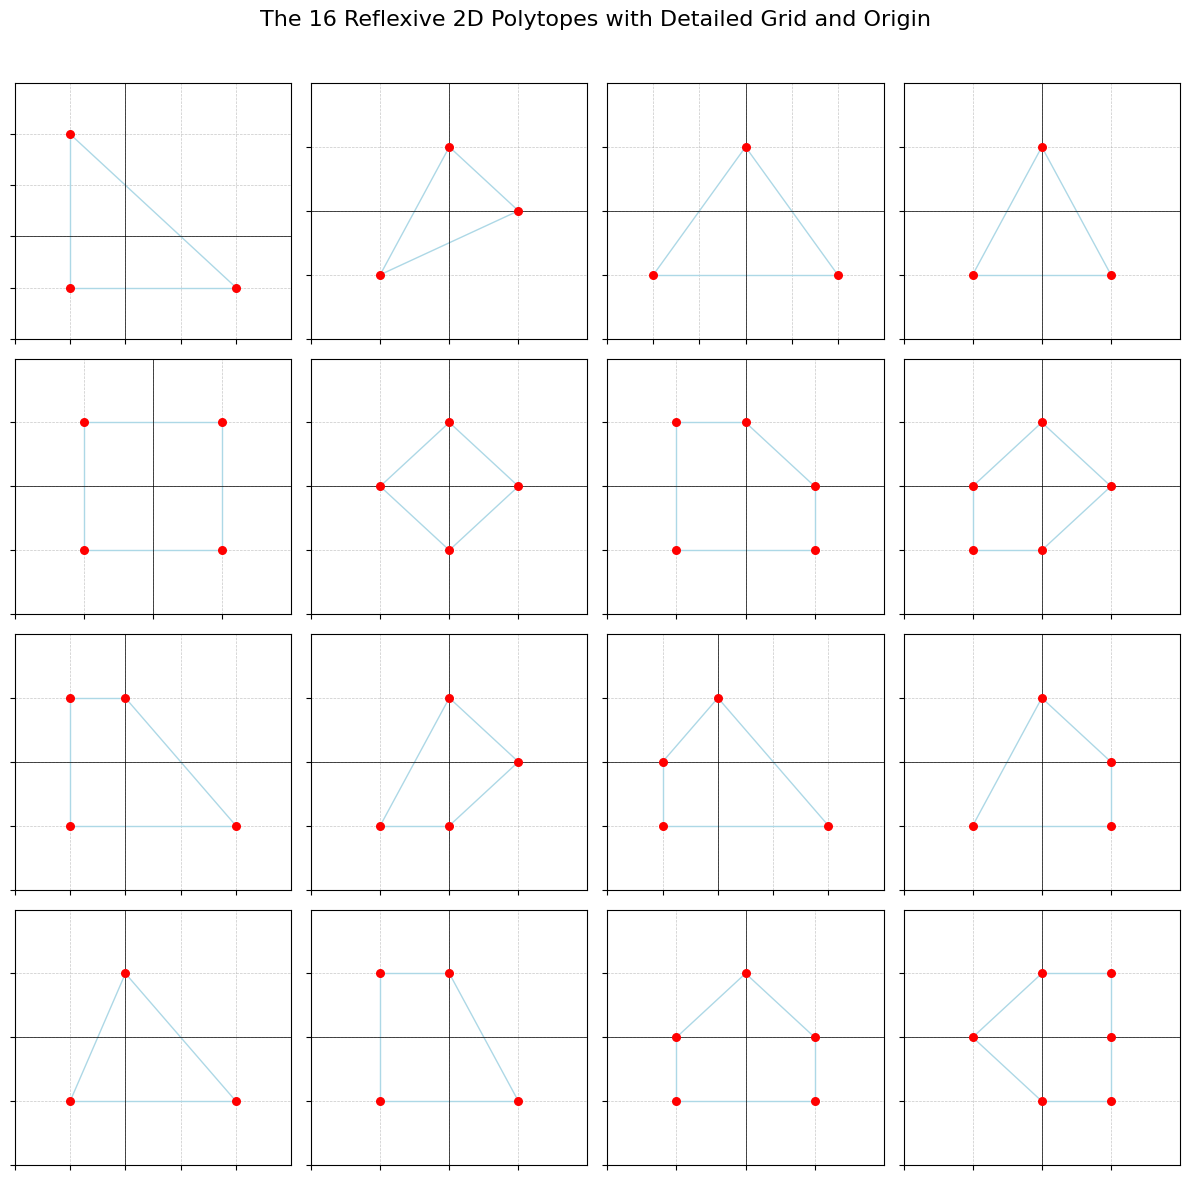

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("16 Reflexive 2D Polytopes", fontsize=16)

for i, (index, row) in enumerate(df_poly2d.iterrows()):
    ax = axes[i // 4, i % 4]  # Determine row and column index in 4x4 grid
    
    # Extract vertices and convert to NumPy array
    V = np.array(row['vertices'])
    
    
    # Alle Punkte zeichnen (auch innenliegende)
    ax.scatter(V[:, 0], V[:, 1], s=30, color="red", zorder=3)

    # Compute convex hull using scipy's ConvexHull
    hull = ConvexHull(V)

    # Plot the polytope by drawing each hull edge
    for simplex in hull.simplices:
        ax.plot(V[simplex, 0], V[simplex, 1], '-', color="lightblue", linewidth=1, zorder=2)
    
    # Add origin and detailed grid
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Set axis limits
    min_V = np.min(V, axis=0)
    max_V = np.max(V, axis=0)
    min_x, min_y = min_V[0] - 1, min_V[1] - 1
    max_x, max_y = max_V[0] + 1, max_V[1] + 1
    
    ax.set_xticks(range(min_x, max_x, 1))
    ax.set_yticks(range(min_y, max_y, 1))
    ax.set_xlim([min_x, max_x])
    ax.set_ylim([min_y, max_y])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.axis("on")

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("The 16 Reflexive 2D Polytopes with Detailed Grid and Origin", fontsize=16)
plt.show()

In [14]:
vertex_counts_sorted_df = (
    df_poly2d["num_vertices"]
    .value_counts()
    .sort_index()
    .rename_axis("vertex_count")   # Index heißt "vertex_count"
    .reset_index(name="count")     # Zählwerte heißen "count"
)

print(vertex_counts_sorted_df)

   vertex_count  count
0             3      5
1             4      7
2             5      3
3             6      1


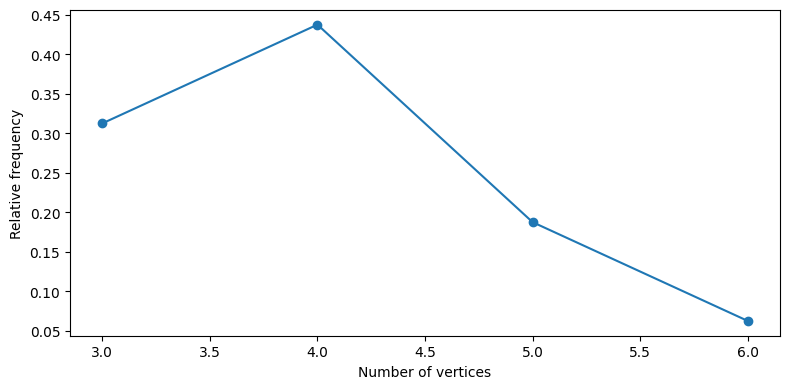

In [16]:
vertex_count_distribution_2d = (df_poly2d["num_vertices"].value_counts().sort_index())

# Normalize the distributions
vertex_count_distribution_2d_norm = (vertex_count_distribution_2d / vertex_count_distribution_2d.sum())

plt.figure(figsize=(8, 4))

plt.plot(
    vertex_count_distribution_2d_norm.index,
    vertex_count_distribution_2d_norm.values,
    marker="o",
    linestyle="-"
)

plt.xlabel("Number of vertices")
plt.ylabel("Relative frequency")

plt.tight_layout()
plt.savefig("../../plot/poly2d-normalized-vertex-dist.png", dpi=300, bbox_inches="tight")
plt.show()